In [47]:
import random
# We simulate the delays for Romeo and Juliet using random numbers between 0 and 1
#Every number represents the delay in part of an hour before they meet.
# The one with the smaller delay arrives first.

def simulate_meeting(trials, acceptable_delay):
    counter = 0
    for i in range(trials):
        romeo_delay = random.random()
        juliet_delay = random.random()
        if abs(romeo_delay - juliet_delay) <= acceptable_delay:
            counter += 1
    return counter / trials

def calculate_probability(acceptable_delay):
    return 1 - (1 - acceptable_delay) ** 2

romeo_delay = random.random()
juliet_delay = random.random()
acceptable_delay = 1/4
exact_probability = calculate_probability(acceptable_delay)
print(f"The exact probability that Romeo and Juliet meet within {acceptable_delay} hours is {exact_probability}")
probability = simulate_meeting(10000000, acceptable_delay)
print(f"The probability that Romeo and Juliet meet within {acceptable_delay} hours is approximately {probability}")
print(f"Error percentage: {abs(exact_probability - probability) / exact_probability * 100:.2f}%")

The exact probability that Romeo and Juliet meet within 0.25 hours is 0.4375
The probability that Romeo and Juliet meet within 0.25 hours is approximately 0.4375228
Error percentage: 0.01%


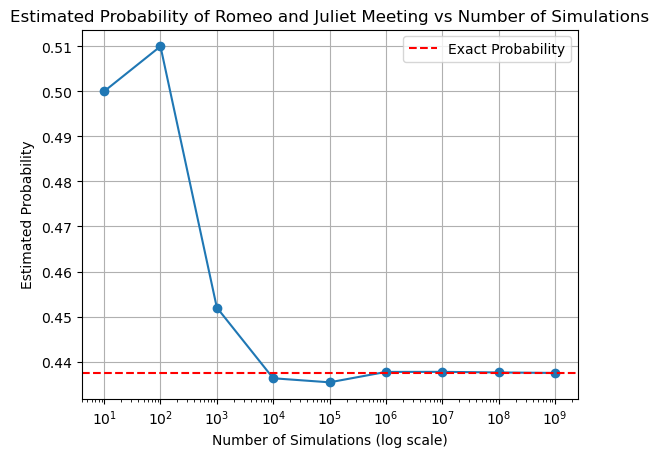

In [45]:
import matplotlib.pyplot as plt 

samples = [10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000]
probabilities = []
for sample in samples:
    probability = simulate_meeting(sample, acceptable_delay)
    probabilities.append(probability)
    
plt.plot(samples, probabilities, marker='o')
plt.axhline(y=exact_probability, color='r', linestyle='--', label='Exact Probability')
plt.xscale('log')   
plt.xlabel('Number of Simulations (log scale)')
plt.ylabel('Estimated Probability')
plt.title('Estimated Probability of Romeo and Juliet Meeting vs Number of Simulations')
plt.legend()
plt.grid()
plt.show()

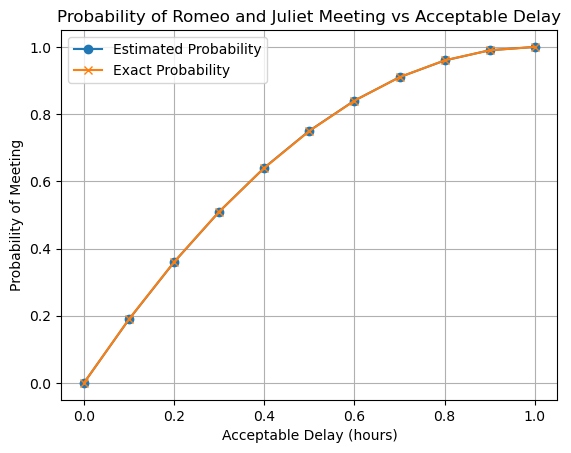

In [51]:
acceptable_delay = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
probabilities = []
for delay in acceptable_delay:
    probability = simulate_meeting(1000000, delay)
    probabilities.append(probability)
exact_probabilities = [calculate_probability(delay) for delay in acceptable_delay]
plt.plot(acceptable_delay, probabilities, marker='o', label='Estimated Probability')
plt.plot(acceptable_delay, exact_probabilities, marker='x', label='Exact Probability')
plt.xlabel('Acceptable Delay (hours)')
plt.ylabel('Probability of Meeting')
plt.title('Probability of Romeo and Juliet Meeting vs Acceptable Delay')
plt.legend()
plt.grid()

In [52]:
#ChatGPT suggested code
import random

def simulate_meeting(n_trials):
    meetings = 0

    for _ in range(n_trials):
        # Romeo and Juliet each arrive with a delay between 0 and 1 hour
        romeo_delay = random.random()
        juliet_delay = random.random()

        # They meet if their arrival times differ by at most 15 minutes = 1/4 hour
        if abs(romeo_delay - juliet_delay) <= 1/4:
            meetings += 1

    probability = meetings / n_trials
    return probability


n_trials = 1_000_000
estimated_probability = simulate_meeting(n_trials)

print("Estimated probability:", estimated_probability)
print("Exact probability:", 7/16)

Estimated probability: 0.438479
Exact probability: 0.4375
